<a href="https://colab.research.google.com/github/ignaciomorenobarria21-a11y/Machine_Learning/blob/main/Sesion_02_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Fundamentos de Machine Learning

## Sesión 2: Clustering con K-Means

**Máster en Formación Permanente en Inteligencia Artificial para el Sector Financiero**  
Universidad Internacional de Valencia · Edición Octubre 2025/26

---

📅 **Fecha:** 8 de enero de 2026  
⏱️ **Duración:** ~100 minutos  
👨‍🏫 **Profesor:** Jaume Antolí Plaza

## 1. Introducción al Clustering

### ¿Qué es el Clustering?

El **clustering** (o agrupamiento) es una técnica de **aprendizaje no supervisado** que busca agrupar datos similares sin necesidad de etiquetas previas.

```
APRENDIZAJE SUPERVISADO          APRENDIZAJE NO SUPERVISADO
─────────────────────────        ──────────────────────────
                                 
  Datos + Etiquetas              Solo Datos
        │                              │
        ▼                              ▼
    ┌───────┐                    ┌───────────┐
    │Modelo │                    │ Algoritmo │
    └───────┘                    └───────────┘
        │                              │
        ▼                              ▼
   Predicción                    Descubrimiento
   de etiquetas                  de patrones
```

### Aplicaciones en Finanzas

- **Identificar regímenes de mercado:** alcista, bajista, lateral
- **Segmentar activos:** por comportamiento, volatilidad, correlación
- **Detectar anomalías:** operaciones fraudulentas, eventos extremos

### El Algoritmo K-Means

K-Means es el algoritmo de clustering más popular. Su objetivo es dividir N observaciones en K grupos (clusters), minimizando la distancia entre cada punto y el centroide de su cluster.

```
ALGORITMO K-MEANS - PASOS
═════════════════════════

1. INICIALIZACIÓN           2. ASIGNACIÓN              3. ACTUALIZACIÓN
   Elegir K centroides         Asignar cada punto         Recalcular centroides
   aleatorios                  al centroide más           como media de puntos
                               cercano                    asignados

   ○     ×                     ○─────×                    ●─────×
      ○                           ○                          ●
   ○                           ○                          ●
                  ×                       ×         (centroide)    ×
      ○     ○                     ○─────○                    ●─────●
   ○                           ○                          ●

                    ◄─────── REPETIR hasta convergencia ───────►
```

### Importancia del Escalado

K-Means utiliza **distancias euclídeas**, por lo que las variables con mayor escala dominarían el resultado. Por eso es **fundamental escalar los datos** antes de aplicar el algoritmo.

## 2. Configuración del Entorno

In [ ]:
# ============================================================
# CONFIGURACIÓN INICIAL
# Ejecuta esta celda antes de continuar (Shift + Enter)
# ============================================================

# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Librerías de Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)

# Ignorar warnings para una salida más limpia
import warnings
warnings.filterwarnings('ignore')

print("✅ Entorno configurado correctamente")

✅ Entorno configurado correctamente


## 3. Cargar el Dataset

Cargamos el dataset que preparamos en la Sesión 1, que contiene datos OHLCV del EUR/USD junto con indicadores técnicos calculados.

In [ ]:
# ============================================================
# CARGA DE DATOS
# Dataset preparado en la Sesión 1 con indicadores técnicos
# ============================================================

# Cargar el dataset directamente desde Google Drive
url = 'https://drive.google.com/uc?id=13vNdqTBl4xZurr1jbcoVHCy9PinJosiL'
df = pd.read_csv(url, index_col=0, parse_dates=True)

print(f"Dataset cargado: {len(df)} filas")
print(f"Período: {df.index[0]} a {df.index[-1]}")
print(f"\nColumnas: {df.columns.tolist()[:10]}...")  # Primeras 10
df.head()

Dataset cargado: 2489 filas
Período: 2010-05-25 00:00:00 a 2019-12-30 00:00:00

Columnas: ['Open', 'High', 'Low', 'Close', 'RSI_2', 'STOCH_2', 'WILLR_2', 'CCI_2', 'ADX_2', 'RSI_3']...


,Open,High,Low,Close,RSI_2,STOCH_2,WILLR_2,CCI_2,ADX_2,RSI_3,...,WILLR_99,CCI_99,ADX_99,RSI_100,STOCH_100,WILLR_100,CCI_100,ADX_100,Target_Return,Target_Direccion
Date,,,,,,,,,,,,,,,,,,,,,
2010-05-25,1.23684,1.23715,1.21747,1.23423,24.421350,41.330435,-57.244898,-12631.780092,58.297675,33.900535,...,-91.817137,-2434.608816,7.508539,27.285877,11.662837,-91.817137,-2415.491160,5.800495,-0.013466,0
2010-05-26,1.23454,1.23870,1.21651,1.21761,8.540825,18.673390,-95.042812,-30614.995315,55.630696,18.773705,...,-98.637557,-2373.603625,7.537198,26.645143,6.291037,-98.637557,-2357.164021,5.842580,0.015128,1
2010-05-27,1.21776,1.23936,1.21498,1.23603,62.538188,44.684518,-13.658737,-27969.102260,58.252217,53.366665,...,-91.078464,-2322.459890,7.568027,28.524123,6.155614,-91.078464,-2306.098927,5.886673,-0.007330,0
2010-05-28,1.23585,1.24518,1.22614,1.22697,39.561528,43.666813,-60.298013,-62192.874981,43.837486,40.607390,...,-94.796454,-2278.999465,7.587006,28.165683,5.162508,-94.796454,-2260.232794,5.919011,0.002812,1
2010-05-31,1.22748,1.23335,1.22568,1.23042,52.775417,50.116981,-75.692308,-55713.249821,31.356454,47.743744,...,-93.380663,-2233.290788,7.606547,28.511223,6.914806,-93.380663,-2215.977269,5.951770,-0.006250,0


## 4. Preparar los Datos para Clustering

Seleccionamos únicamente las columnas de indicadores técnicos (excluyendo OHLCV y targets) y aplicamos escalado.

In [ ]:
# ============================================================
# PREPARACIÓN DE DATOS
# Seleccionar indicadores y escalar
# ============================================================

# Seleccionar columnas de indicadores (excluir OHLCV y targets)
# Estructura: Open, High, Low, Close, Volume, [indicadores...], Target_Return, Target_Direccion
columnas_indicadores = df.columns[5:-2].tolist()

print(f"Número de indicadores: {len(columnas_indicadores)}")
print(f"Ejemplos: {columnas_indicadores[:5]}")

# Crear matriz de features
X = df[columnas_indicadores].copy()

# Escalar los datos (fundamental para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ Datos preparados: {X_scaled.shape[0]} muestras, {X_scaled.shape[1]} features")

Número de indicadores: 494
Ejemplos: ['STOCH_2', 'WILLR_2', 'CCI_2', 'ADX_2', 'RSI_3']

✅ Datos preparados: 2489 muestras, 494 features


## 5. Clustering con K=2

Comenzamos con 2 clusters para identificar dos "estados" del mercado.

In [ ]:
# ============================================================
# K-MEANS CON 2 CLUSTERS
# ============================================================

# Crear y entrenar el modelo
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_2 = kmeans_2.fit_predict(X_scaled)

# Contar observaciones por cluster
unique, counts = np.unique(clusters_2, return_counts=True)
print("Distribución de clusters (K=2):")
for c, n in zip(unique, counts):
    print(f"  Cluster {c}: {n} observaciones ({n/len(clusters_2)*100:.1f}%)")

Distribución de clusters (K=2):
  Cluster 0: 1266 observaciones (50.9%)
  Cluster 1: 1223 observaciones (49.1%)


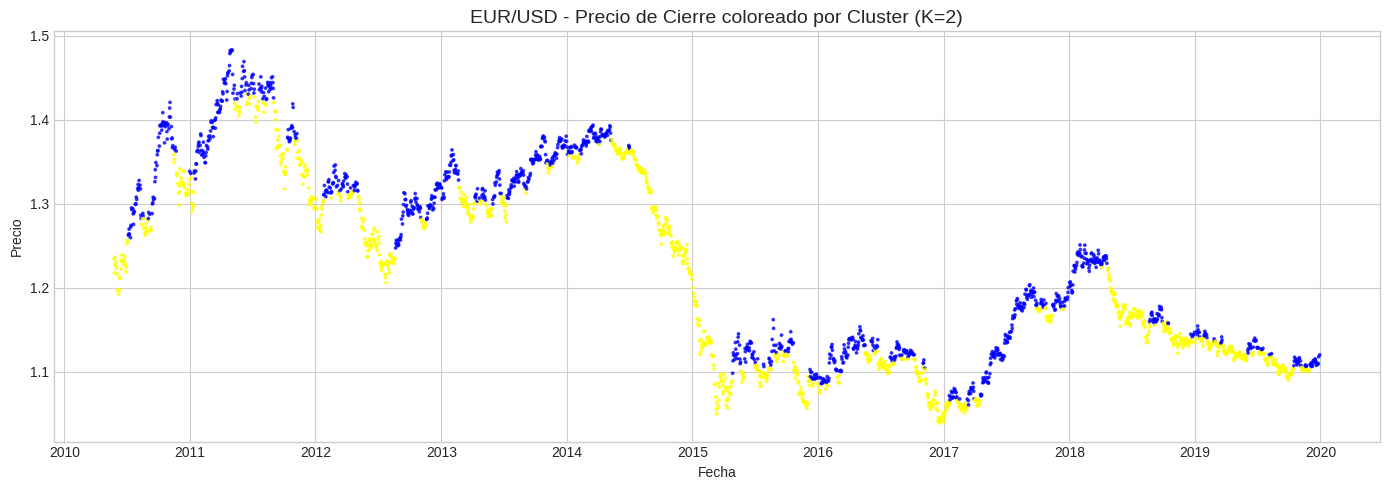

🔵 Azul = Cluster 0
🟡 Amarillo = Cluster 1


In [ ]:
# ============================================================
# VISUALIZACIÓN K=2
# Precio de cierre coloreado por cluster
# ============================================================

# Definir colores para cada cluster
colores_2 = ['blue' if c == 0 else 'yellow' for c in clusters_2]

# Crear gráfico
plt.figure(figsize=(14, 5))
plt.scatter(df.index, df['Close'], c=colores_2, s=3, alpha=0.7)
plt.title('EUR/USD - Precio de Cierre coloreado por Cluster (K=2)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.tight_layout()
plt.show()

print("🔵 Azul = Cluster 0")
print("🟡 Amarillo = Cluster 1")

## 6. Clustering con K=3 (Sistema Semáforo)

Con 3 clusters podemos identificar tres estados de mercado:
- 🟢 **Verde:** Mercado alcista
- 🟠 **Naranja:** Zona de transición
- 🔴 **Rojo:** Mercado bajista

In [ ]:
# ============================================================
# K-MEANS CON 3 CLUSTERS
# ============================================================

# Crear y entrenar el modelo
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_3 = kmeans_3.fit_predict(X_scaled)

# Añadir clusters al dataframe para análisis
df['Cluster'] = clusters_3

# Calcular SMA(20) para identificar el estado actual del mercado
df['SMA20'] = df['Close'].rolling(20).mean()
df['Diff_SMA'] = df['Close'] - df['SMA20']  # Positivo = por encima de media

# Calcular diferencia media vs SMA por cluster
print("Diferencia media vs SMA(20) por cluster:")
diff_por_cluster = df.groupby('Cluster')['Diff_SMA'].mean()
print(diff_por_cluster)

# Identificar clusters por posición respecto a la media
cluster_verde = diff_por_cluster.idxmax()    # Mayor diff = por encima de media = alcista
cluster_rojo = diff_por_cluster.idxmin()     # Menor diff = por debajo de media = bajista
cluster_naranja = [c for c in [0, 1, 2] if c not in [cluster_verde, cluster_rojo]][0]

print(f"\n🟢 Verde (alcista): Cluster {cluster_verde}")
print(f"🟠 Naranja (transición): Cluster {cluster_naranja}")
print(f"🔴 Rojo (bajista): Cluster {cluster_rojo}")

Diferencia media vs SMA(20) por cluster:
Cluster
0    0.013040
1   -0.004966
2   -0.015127
Name: Diff_SMA, dtype: float64

🟢 Verde (alcista): Cluster 0
🟠 Naranja (transición): Cluster 1
🔴 Rojo (bajista): Cluster 2


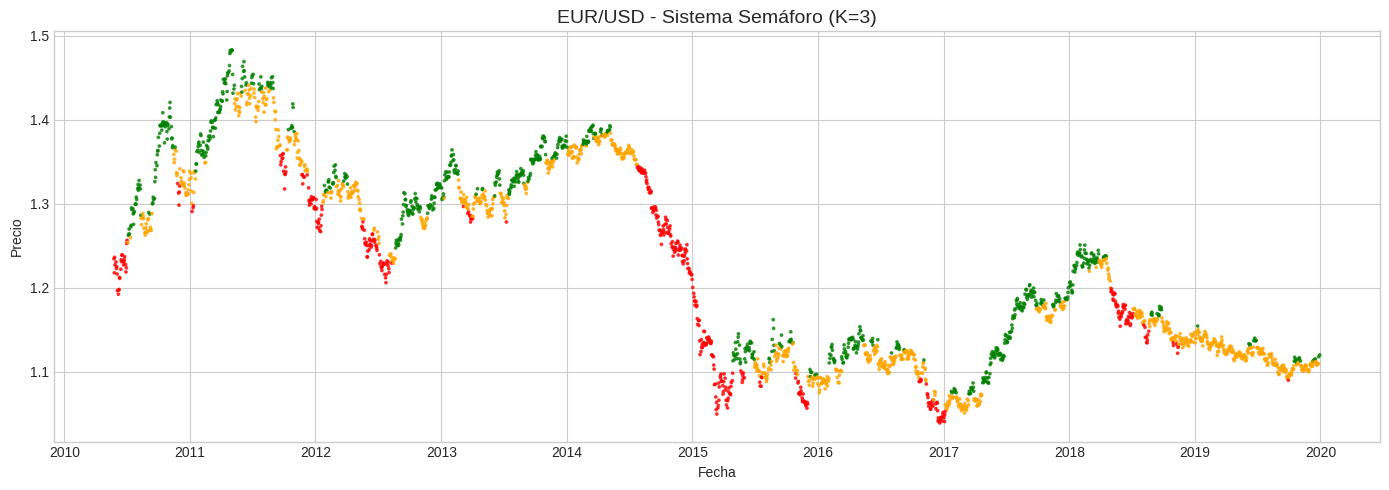

🟢 Verde = Mercado alcista
🟠 Naranja = Zona de transición
🔴 Rojo = Mercado bajista


In [ ]:
# ============================================================
# VISUALIZACIÓN K=3 (SEMÁFORO)
# ============================================================

# Crear mapeo de colores
mapeo_colores = {
    cluster_verde: 'green',
    cluster_naranja: 'orange',
    cluster_rojo: 'red'
}

colores_3 = [mapeo_colores[c] for c in clusters_3]

# Crear gráfico
plt.figure(figsize=(14, 5))
plt.scatter(df.index, df['Close'], c=colores_3, s=3, alpha=0.7)
plt.title('EUR/USD - Sistema Semáforo (K=3)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.tight_layout()
plt.show()

print("🟢 Verde = Mercado alcista")
print("🟠 Naranja = Zona de transición")
print("🔴 Rojo = Mercado bajista")

## 7. Sistema de Trading basado en Clusters

Vamos a construir un sistema de trading **anticipativo** basado en las **transiciones** entre clusters:

```
REGLAS DEL SISTEMA (ANTICIPATIVO)
══════════════════════════════════

    🟢 ──────► 🟠    =    ABRIR SHORT (fin de subidas, anticipamos caída)
    🔴 ──────► 🟠    =    CERRAR SHORT / ABRIR LONG
    
    🔴 ──────► 🟠    =    ABRIR LONG (fin de bajadas, anticipamos subida)
    🟢 ──────► 🟠    =    CERRAR LONG / ABRIR SHORT
```

La idea es usar la transición a naranja como señal de que el régimen anterior ha terminado, y nos posicionamos anticipando el siguiente movimiento.

In [ ]:
# ============================================================
# CREAR SEÑALES DE TRADING (SISTEMA ANTICIPATIVO)
# ============================================================

# Crear columna de semáforo con nombres descriptivos
mapeo_semaforo = {
    cluster_verde: 'verde',
    cluster_naranja: 'naranja',
    cluster_rojo: 'rojo'
}
df['Semaforo'] = df['Cluster'].map(mapeo_semaforo)

# Detectar el semáforo anterior
df['Semaforo_Anterior'] = df['Semaforo'].shift(1)

# Inicializar columna de posición
df['Posicion'] = 0  # 0 = fuera, 1 = long, -1 = short

# Recorrer el dataframe para determinar posiciones
posicion_actual = 0

for i in range(1, len(df)):
    anterior = df['Semaforo_Anterior'].iloc[i]
    actual = df['Semaforo'].iloc[i]

    # SHORT: Verde → Naranja (fin de subidas, anticipamos caída)
    # Cerrar SHORT: Rojo → Naranja (fin de bajadas)
    if anterior == 'verde' and actual == 'naranja':
        posicion_actual = -1  # Abrir SHORT
    elif anterior == 'rojo' and actual == 'naranja':
        posicion_actual = 1   # Abrir LONG (y cerrar SHORT si había)

    # LONG: Rojo → Naranja (fin de bajadas, anticipamos subida)
    # Cerrar LONG: Verde → Naranja (fin de subidas)
    # (ya cubierto arriba: verde→naranja abre short, cerrando long implícitamente)

    df.iloc[i, df.columns.get_loc('Posicion')] = posicion_actual

# Mostrar distribución de posiciones
print("Distribución de posiciones:")
print(df['Posicion'].value_counts().sort_index())
print(f"\n  -1 = SHORT")
print(f"   0 = Fuera del mercado")
print(f"   1 = LONG")

Distribución de posiciones:
Posicion
-1    1973
 0      29
 1     487
Name: count, dtype: int64

  -1 = SHORT
   0 = Fuera del mercado
   1 = LONG


## 8. Calcular la Curva de Resultados

Para calcular los resultados:
- **Posición LONG (+1):** sumamos el retorno normal
- **Posición SHORT (-1):** sumamos el retorno invertido
- **Fuera (0):** no sumamos nada

Usamos `cumsum()` para obtener la curva acumulada.

In [ ]:
# ============================================================
# CALCULAR RESULTADOS DEL SISTEMA
# ============================================================

# El retorno del sistema es: posición * retorno del activo
# - Si estamos LONG (1): ganamos si el activo sube
# - Si estamos SHORT (-1): ganamos si el activo baja (retorno invertido)
# - Si estamos FUERA (0): no ganamos ni perdemos

df['Retorno_Sistema'] = df['Posicion'] * df['Target_Return']

# Curva de equity (resultados acumulados)
df['Equity'] = df['Retorno_Sistema'].cumsum()

# También calculamos el buy & hold para comparar
df['Equity_BuyHold'] = df['Target_Return'].cumsum()

print("Resultados calculados correctamente")
print(f"\nRetorno total del sistema: {df['Equity'].iloc[-1]:.4f}")
print(f"Retorno total Buy & Hold: {df['Equity_BuyHold'].iloc[-1]:.4f}")

Resultados calculados correctamente

Retorno total del sistema: 0.1384
Retorno total Buy & Hold: -0.0656


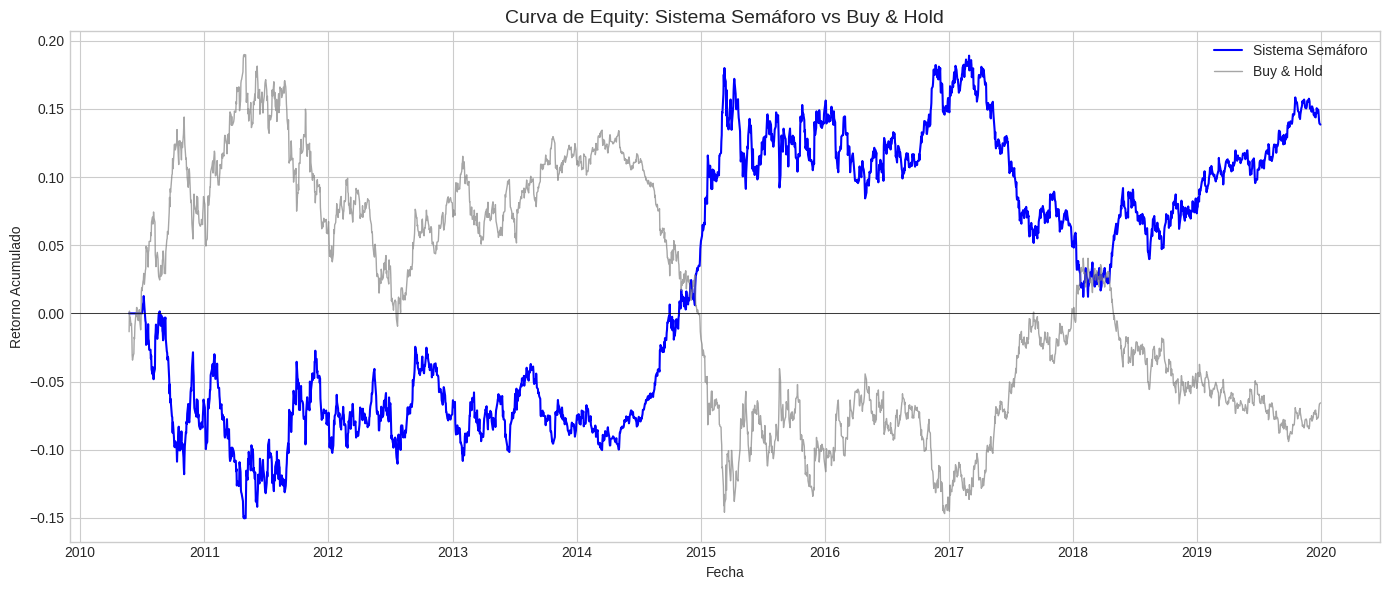

In [ ]:
# ============================================================
# VISUALIZAR CURVA DE EQUITY
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(df.index, df['Equity'], label='Sistema Semáforo', linewidth=1.5, color='blue')
plt.plot(df.index, df['Equity_BuyHold'], label='Buy & Hold', linewidth=1, color='gray', alpha=0.7)

plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Curva de Equity: Sistema Semáforo vs Buy & Hold', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Retorno Acumulado')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ESTADÍSTICAS DEL SISTEMA
# ============================================================

# Filtrar solo los días que estuvimos en el mercado
df_en_mercado = df[df['Posicion'] != 0]

# Calcular estadísticas
retorno_total = df['Equity'].iloc[-1]
dias_totales = len(df)
dias_en_mercado = len(df_en_mercado)
dias_long = len(df[df['Posicion'] == 1])
dias_short = len(df[df['Posicion'] == -1])

# Retorno medio por operación
if dias_en_mercado > 0:
    retorno_medio = df_en_mercado['Retorno_Sistema'].mean()
else:
    retorno_medio = 0

print("=" * 50)
print("ESTADÍSTICAS DEL SISTEMA SEMÁFORO")
print("=" * 50)
print(f"\nRetorno total:          {retorno_total:.4f} ({retorno_total*100:.2f}%)")
print(f"Retorno medio diario:   {retorno_medio:.6f}")
print(f"\nDías totales:           {dias_totales}")
print(f"Días en mercado:        {dias_en_mercado} ({dias_en_mercado/dias_totales*100:.1f}%)")
print(f"  - Días en LONG:       {dias_long}")
print(f"  - Días en SHORT:      {dias_short}")
print("=" * 50)

ESTADÍSTICAS DEL SISTEMA SEMÁFORO

Retorno total:          0.1384 (13.84%)
Retorno medio diario:   0.000056

Días totales:           2489
Días en mercado:        2460 (98.8%)
  - Días en LONG:       487
  - Días en SHORT:      1973


## 9. Resumen y Conclusiones

### Lo que hemos aprendido:

1. **Clustering** es una técnica de aprendizaje no supervisado que agrupa datos similares

2. **K-Means** es el algoritmo más popular, que requiere:
   - Definir el número de clusters (K)
   - **Escalar los datos** previamente

3. En finanzas, podemos usar clustering para **identificar regímenes de mercado**

4. Con K=3 creamos un **sistema semáforo**:
   - 🟢 Verde = alcista
   - 🟠 Naranja = transición
   - 🔴 Rojo = bajista

5. Las **transiciones** entre clusters pueden generar señales de trading

### ⚠️ Advertencia importante

Este sistema es **puramente educativo**. En un entorno real:
- Debemos validar con datos fuera de muestra (out-of-sample)
- Hay que considerar costes de transacción y slippage
- El clustering puede cambiar con nuevos datos

### Próxima sesión

En la **Sesión 3** aprenderemos sobre **Regresión**, donde intentaremos predecir valores numéricos (como el retorno futuro) en lugar de clasificar en grupos.